In [2]:
import pandas as pd
import numpy as np

# Load data
raw = pd.read_csv('/Users/wiktor/TIC/Spring2026-TIC/data/merged_prices_weather.csv')

raw['date'] = pd.to_datetime(raw['date'])

# Identify column groups (price is equal across locations, so we can separate it from location-specific weather)
price_cols   = ['corn_Close', 'corn_Volume', 'corn_log_return',
                'soybean_Close', 'soybean_Volume', 'soybean_log_return']
meta_cols    = ['date', 'Latitude', 'Longitude', 'Location_ID']
weather_cols = [c for c in raw.columns if c not in price_cols + meta_cols]

# Price table: one row per date (prices are identical across locations)
prices = (
    raw.groupby('date')[price_cols]
       .first()
       .reset_index()
)

# Weather table: pivot to wide format(one row per date, separate columns for each location)
raw_weather = raw.dropna(subset=['Location_ID']).copy()
raw_weather['Location_ID'] = raw_weather['Location_ID'].astype(int)
weather_wide = raw.pivot(index='date', columns='Location_ID', values=weather_cols)
weather_wide.columns = [f"{var}_loc{loc}" for var, loc in weather_wide.columns]
weather_wide = weather_wide.reset_index()

# Merge
data = prices.merge(weather_wide, on='date')

# Set date index & deduplicate
data['date'] = pd.to_datetime(data['date'])
data = data.set_index('date')
data = data[~data.index.duplicated(keep='first')]
data = data.sort_index()

print(f"Wide dataset shape: {data.shape}")
print(f"Date range: {data.index.min().date()} → {data.index.max().date()}")
print(f"Columns ({len(data.columns)} total):")
print(data.columns.tolist()[:10], "...")  # preview first 10
data.head(3)

Wide dataset shape: (5305, 162)
Date range: 2005-01-03 → 2026-02-02
Columns (162 total):
['corn_Close', 'corn_Volume', 'corn_log_return', 'soybean_Close', 'soybean_Volume', 'soybean_log_return', 'temperature_2m_mean_locnan', 'temperature_2m_mean_loc1.0', 'temperature_2m_mean_loc2.0', 'temperature_2m_mean_loc3.0'] ...


,corn_Close,corn_Volume,corn_log_return,soybean_Close,soybean_Volume,soybean_log_return,temperature_2m_mean_locnan,temperature_2m_mean_loc1.0,temperature_2m_mean_loc2.0,temperature_2m_mean_loc3.0,...,soil_temperature_0_to_7cm_mean_loc2.0,soil_temperature_0_to_7cm_mean_loc3.0,soil_temperature_28_to_100cm_mean_locnan,soil_temperature_28_to_100cm_mean_loc1.0,soil_temperature_28_to_100cm_mean_loc2.0,soil_temperature_28_to_100cm_mean_loc3.0,soil_temperature_7_to_28cm_mean_locnan,soil_temperature_7_to_28cm_mean_loc1.0,soil_temperature_7_to_28cm_mean_loc2.0,soil_temperature_7_to_28cm_mean_loc3.0
date,,,,,,,,,,,,,,,,,,,,,
2005-01-03,201.75,1743.0,0.000000,537.25,47,0.000000,NaN,11.580083,9.055416,6.513833,...,10.184585,5.168000,NaN,5.542584,13.367916,6.813833,NaN,8.771749,10.949168,5.303416
2005-01-04,201.00,1357.0,-0.003724,529.75,54,-0.014058,NaN,4.525917,7.024166,8.643000,...,8.736667,7.170083,NaN,6.175917,13.167916,6.861749,NaN,7.267583,10.107500,6.636750
2005-01-05,201.50,1159.0,0.002484,534.00,37,0.007991,NaN,0.390500,7.551250,5.203417,...,8.428333,4.782584,NaN,6.390499,12.880416,6.942999,NaN,5.090500,9.442917,5.793000


Estimating beta with 1-year rolling window (no look-ahead bias)...
Window size: 400 trading days

Total rows available: 5303
✓ Beta estimation complete. First 400 rows have NaN (insufficient history).

BETA STATISTICS (Rolling 1-Year Window)
Mean:   0.8908
Median: 0.7754
Std:    0.5938
Min:    -0.0441
Max:    2.8340
Range:  2.8781

COINTEGRATION TEST (on rolling-window spread)
ADF Statistic: -5.4975
P-Value:       0.00000
Result: COINTEGRATION DETECTED — spread is mean-reverting ✓


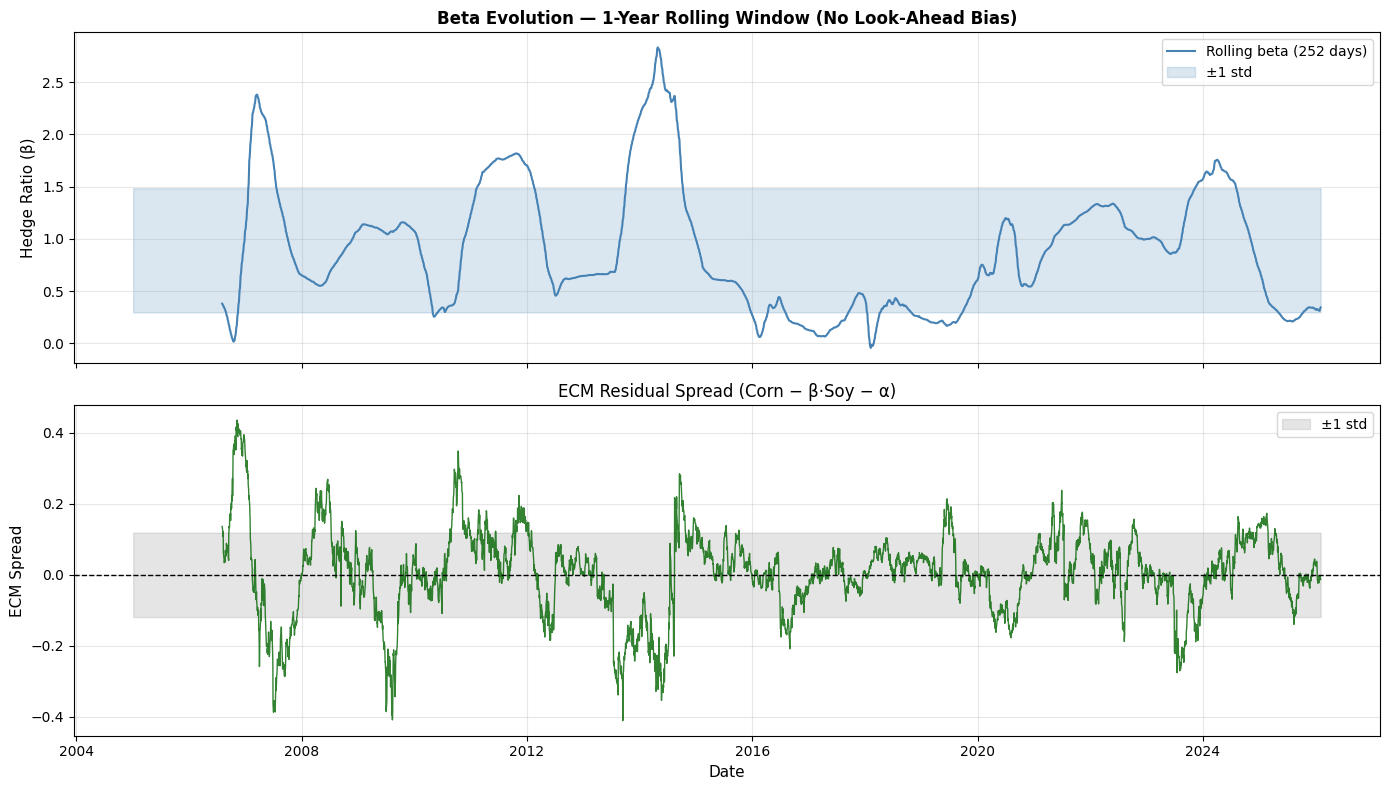

In [3]:
import statsmodels.api as sm
import statsmodels.tsa.stattools as ts
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Rolling Window Beta Estimation

WINDOW = 400  # 1 trading year

print("Estimating beta with 1-year rolling window (no look-ahead bias)...")
print(f"Window size: {WINDOW} trading days\n")

# Prepare log prices
log_corn = np.log(data['corn_Close'])
log_soy = np.log(data['soybean_Close'])

# Drop any NaNs or zeros
valid_idx = (data['corn_Close'] > 0) & (data['soybean_Close'] > 0)
log_corn = log_corn[valid_idx]
log_soy = log_soy[valid_idx]

print(f"Total rows available: {len(log_corn)}")

# Initialize results
data['beta'] = np.nan
data['alpha'] = np.nan
data['ecm_spread'] = np.nan

# Rolling window estimation
for i in range(WINDOW, len(log_corn)):
    # Training window: PAST 252 days (not including current day; no look-ahead)
    train_log_corn = log_corn.iloc[i-WINDOW:i]
    train_log_soy = log_soy.iloc[i-WINDOW:i]
    
    # Estimate beta and alpha on training window
    X = sm.add_constant(train_log_soy)
    try:
        ols = sm.OLS(train_log_corn, X).fit()
        beta_t = ols.params.iloc[1]  # FIX: use iloc[1] for slope
        alpha_t = ols.params.iloc[0]  # FIX: use iloc[0] for intercept
    except:
        # If OLS fails, use previous values
        beta_t = data['beta'].iloc[i-1] if i > WINDOW else np.nan
        alpha_t = data['alpha'].iloc[i-1] if i > WINDOW else np.nan
    
    # Store parameters for this date
    current_idx = log_corn.index[i]
    data.loc[current_idx, 'beta'] = beta_t
    data.loc[current_idx, 'alpha'] = alpha_t
    
    # Compute spread using beta/alpha from PAST data only
    data.loc[current_idx, 'ecm_spread'] = (
        log_corn.iloc[i] - beta_t * log_soy.iloc[i] - alpha_t
    )

print(f"✓ Beta estimation complete. First {WINDOW} rows have NaN (insufficient history).\n")

# Summary Statistics

valid_beta = data['beta'].dropna()

print("=" * 80)
print("BETA STATISTICS (Rolling 1-Year Window)")
print("=" * 80)
print(f"Mean:   {valid_beta.mean():.4f}")
print(f"Median: {valid_beta.median():.4f}")
print(f"Std:    {valid_beta.std():.4f}")
print(f"Min:    {valid_beta.min():.4f}")
print(f"Max:    {valid_beta.max():.4f}")
print(f"Range:  {valid_beta.max() - valid_beta.min():.4f}")

# Cointegration Test on the Spread

valid_spread = data['ecm_spread'].dropna()

adf_stat, adf_p, _, _, _, _ = ts.adfuller(valid_spread)
print(f"\n" + "=" * 80)
print("COINTEGRATION TEST (on rolling-window spread)")
print("=" * 80)
print(f"ADF Statistic: {adf_stat:.4f}")
print(f"P-Value:       {adf_p:.5f}")
if adf_p < 0.05:
    print("Result: COINTEGRATION DETECTED — spread is mean-reverting ✓")
else:
    print("Result: NO COINTEGRATION at 5% level ✗")

# Visualization

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top: Beta over time
ax1.plot(data.index, data['beta'], linewidth=1.5, label='Rolling beta (252 days)', color='steelblue')
ax1.fill_between(data.index, 
                  valid_beta.mean() - valid_beta.std(),
                  valid_beta.mean() + valid_beta.std(),
                  alpha=0.2, color='steelblue', label='±1 std')
ax1.set_ylabel('Hedge Ratio (β)', fontsize=11)
ax1.set_title('Beta Evolution — 1-Year Rolling Window (No Look-Ahead Bias)', fontsize=12, fontweight='bold')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# Bottom: ECM Spread
ax2.plot(data.index, data['ecm_spread'], linewidth=1, color='darkgreen', alpha=0.8)
ax2.axhline(0, color='black', linestyle='--', linewidth=1)
ax2.fill_between(data.index, -valid_spread.std(), valid_spread.std(), 
                  alpha=0.2, color='gray', label='±1 std')
ax2.set_xlabel('Date', fontsize=11)
ax2.set_ylabel('ECM Spread', fontsize=11)
ax2.set_title('ECM Residual Spread (Corn − β·Soy − α)', fontsize=12)
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
"""
Triple Barrier Method — Fixed & Improved
=========================================
Replaces Cells 11 + 13 in validation_Roos_changed.ipynb

Fixes applied:
  1. CUSUM filter for event selection (replaces every-day sampling)
  2. Vertical barrier uses TRADING days, not calendar days
  3. Side parameter correctly used in barrier computation
  4. get_bins edge case: PT/SL on same day as vertical barrier handled correctly
  5. Diagnostic prints to verify event spacing and label distribution
"""

import numpy as np
import pandas as pd
import statsmodels.api as sm

# ─────────────────────────────────────────────────────────────────────────────
# 1. Daily volatility (unchanged from original — this part was correct)
# ─────────────────────────────────────────────────────────────────────────────

def get_daily_vol(series, span=100):
    """Exponentially-weighted std of daily changes in the spread."""
    return series.diff().ewm(span=span).std()


daily_vol = get_daily_vol(data['ecm_spread'])


# ─────────────────────────────────────────────────────────────────────────────
# 2. Symmetric CUSUM filter  (AFML Ch.2, Snippet 2.4)
#    Detects meaningful shifts in the spread before opening a new event.
#    Replaces `t_events = data.index` (every day).
# ─────────────────────────────────────────────────────────────────────────────

def cusum_filter(spread, threshold):
    """
    Symmetric CUSUM filter on the ECM spread.

    Accumulates positive and negative deviations separately.
    Fires an event (and resets) when either cumulative sum exceeds
    the threshold. This avoids whipsawing around the boundary and
    ensures events are meaningfully spaced.

    Parameters
    ----------
    spread    : pd.Series — the ECM residual spread
    threshold : pd.Series or float — firing threshold at each point
                (typically daily_vol or a scalar multiple of it)

    Returns
    -------
    pd.DatetimeIndex of event timestamps
    """
    t_events = []
    s_pos, s_neg = 0.0, 0.0
    diff = spread.diff().dropna()

    for t, delta in diff.items():
        # Threshold can be time-varying (pd.Series) or fixed (float)
        h = threshold.loc[t] if isinstance(threshold, pd.Series) else threshold

        # Skip if threshold is NaN (early period before vol is available)
        if np.isnan(h):
            continue

        s_pos = max(0.0, s_pos + delta)
        s_neg = min(0.0, s_neg + delta)

        if s_neg < -h:
            s_neg = 0.0
            t_events.append(t)
        elif s_pos > h:
            s_pos = 0.0
            t_events.append(t)

    return pd.DatetimeIndex(t_events)


# Fire events when cumulative spread movement exceeds 1× daily vol.
# You can tune this multiplier: lower = more events, higher = fewer events.
CUSUM_MULTIPLIER = 1.0

cusum_threshold = daily_vol * CUSUM_MULTIPLIER
t_events = cusum_filter(data['ecm_spread'], cusum_threshold)

print(f"CUSUM filter: {len(t_events)} events from {len(data)} trading days "
      f"({100 * len(t_events) / len(data):.1f}% sampling rate)")

# Diagnostic: check event spacing
if len(t_events) > 1:
    gaps = pd.Series(t_events).diff().dt.days.dropna()
    print(f"  Median gap between events: {gaps.median():.0f} calendar days")
    print(f"  Mean gap:                  {gaps.mean():.1f} calendar days")
    print(f"  Min / Max gap:             {gaps.min():.0f} / {gaps.max():.0f} days")


# ─────────────────────────────────────────────────────────────────────────────
# 3. Vertical barriers — FIX: use TRADING days, not calendar days
# ─────────────────────────────────────────────────────────────────────────────

HOLDING_PERIOD = 60  # trading days (not calendar days)

def add_vertical_barrier(t_events, close, num_days):
    """
    For each event, find the index of the bar `num_days` trading days later.
    Clips to the last available bar for events near the end of the series.
    """
    # Map each event timestamp to its integer position in close.index
    positions = close.index.searchsorted(t_events)

    # Shift forward by num_days trading bars
    end_positions = np.minimum(positions + num_days, len(close.index) - 1)

    return pd.Series(close.index[end_positions], index=t_events)


t1 = add_vertical_barrier(t_events, data['ecm_spread'], HOLDING_PERIOD)

print(f"\nVertical barriers set at {HOLDING_PERIOD} trading days")


# ─────────────────────────────────────────────────────────────────────────────
# 4. apply_pt_sl_on_t1 — FIX: incorporate side into barrier direction
# ─────────────────────────────────────────────────────────────────────────────

def apply_pt_sl_on_t1(close, events, pt_sl, molecule):
    """
    Scan each event's price path and record when (if ever) the
    profit-take (pt) or stop-loss (sl) barrier is first breached.

    FIX: barriers are now side-aware.
    - If side = +1 (long spread), PT is hit when spread goes UP, SL when DOWN.
    - If side = -1 (short spread), PT is hit when spread goes DOWN, SL when UP.

    Parameters
    ----------
    close     : spread series
    events    : DataFrame with columns ['t1', 'trgt', 'side']
    pt_sl     : [sl_multiplier, pt_multiplier]
    molecule  : index subset to process
    """
    events_ = events.loc[molecule]
    out = events_[['t1']].copy(deep=True)

    # Width of barriers (always positive)
    pt_width = pt_sl[1] * events_['trgt'] if pt_sl[1] > 0 else pd.Series(np.nan, index=events_.index)
    sl_width = pt_sl[0] * events_['trgt'] if pt_sl[0] > 0 else pd.Series(np.nan, index=events_.index)

    for loc, t1_val in events_['t1'].fillna(close.index[-1]).items():
        path = close[loc:t1_val]
        path = (path - close[loc]) * events_.at[loc, 'side']  # FIX: multiply by side

        # PT: path exceeds +pt_width  (profit in the direction of our bet)
        # SL: path drops below -sl_width (loss against our bet)
        out.loc[loc, 'pt'] = path[path > pt_width[loc]].index.min() if not np.isnan(pt_width[loc]) else pd.NaT
        out.loc[loc, 'sl'] = path[path < -sl_width[loc]].index.min() if not np.isnan(sl_width[loc]) else pd.NaT

    return out


# ─────────────────────────────────────────────────────────────────────────────
# 5. get_events  (structurally unchanged, just uses CUSUM-filtered t_events)
# ─────────────────────────────────────────────────────────────────────────────

def get_events(close, t_events, pt_sl, target, min_ret,
               vertical_barrier_times=False, side=None):
    """
    Build an events DataFrame and apply the triple barrier.
    """
    # Filter on minimum volatility
    target = target.reindex(t_events).dropna()
    target = target[target > min_ret]

    # Vertical barrier
    if vertical_barrier_times is not False:
        t1 = vertical_barrier_times.reindex(target.index)
    else:
        t1 = pd.Series(pd.NaT, index=target.index)

    # Side (default: always long, i.e. 1.0)
    side_ = side.reindex(target.index) if side is not None \
            else pd.Series(1.0, index=target.index)

    # Build events DataFrame — only keep rows where all three are available
    events = pd.DataFrame({
        't1':   t1,
        'trgt': target,
        'side': side_,
    }).dropna(subset=['trgt'])

    # Apply barriers
    df0 = apply_pt_sl_on_t1(close=close, events=events,
                             pt_sl=pt_sl, molecule=events.index)

    # First barrier touched (earliest of pt, sl, t1)
    events['t1'] = df0.dropna(how='all').min(axis=1)

    return events


# ─────────────────────────────────────────────────────────────────────────────
# 6. Run triple barrier on CUSUM-filtered events
# ─────────────────────────────────────────────────────────────────────────────

events = get_events(
    close=data['ecm_spread'],
    t_events=t_events,               # <-- CUSUM-filtered, NOT data.index
    pt_sl=[1, 1],                     # symmetric ±1σ barriers
    target=daily_vol,
    min_ret=0.005,
    vertical_barrier_times=t1,
)

print(f"\nEvents after get_events: {events.shape[0]}")


# ─────────────────────────────────────────────────────────────────────────────
# 7. get_bins — FIX: handle edge case where PT/SL hits on same day as t1
# ─────────────────────────────────────────────────────────────────────────────

def get_bins(events, close, t1_original):
    """
    Label each event based on which barrier was hit first.

    Returns a DataFrame with:
        ret : realised change in spread from entry to first barrier touch
        bin : +1 (PT hit), -1 (SL hit), 0 (vertical barrier / time-out)

    FIX: if PT or SL fires on exactly the same day as the vertical barrier,
         it is correctly labelled as ±1 (not 0).
    """
    events_ = events.dropna(subset=['t1'])

    # Re-run barrier detection to know WHICH barrier was hit first
    df0 = apply_pt_sl_on_t1(close=close, events=events_,
                             pt_sl=[1, 1], molecule=events_.index)

    entry_spread = close.reindex(events_.index)
    exit_spread  = close.reindex(events_['t1'])

    out = pd.DataFrame(index=events_.index)
    out['ret'] = exit_spread.values - entry_spread.values
    out['bin'] = np.sign(out['ret'])  # default: sign of return

    for idx in events_.index:
        pt_time = df0.at[idx, 'pt'] if pd.notna(df0.at[idx, 'pt']) else pd.Timestamp.max
        sl_time = df0.at[idx, 'sl'] if pd.notna(df0.at[idx, 'sl']) else pd.Timestamp.max
        vb_time = t1_original.at[idx] if idx in t1_original.index else pd.Timestamp.max

        first = min(pt_time, sl_time, vb_time)

        if first == pt_time and pd.notna(df0.at[idx, 'pt']):
            out.at[idx, 'bin'] = 1.0       # profit-take hit first (or tied)
        elif first == sl_time and pd.notna(df0.at[idx, 'sl']):
            out.at[idx, 'bin'] = -1.0       # stop-loss hit first
        else:
            out.at[idx, 'bin'] = 0.0        # vertical barrier (true timeout)

    return out


labels = get_bins(events, data['ecm_spread'], t1)

print("\nLabel distribution:")
print(labels['bin'].value_counts().sort_index())
print(f"\nTotal labelled events: {len(labels)}")

# Diagnostic: check for event overlap
if len(labels) > 1:
    holding = (events['t1'] - events.index).dt.days
    print(f"\nHolding period stats (calendar days):")
    print(f"  Mean:   {holding.mean():.1f}")
    print(f"  Median: {holding.median():.1f}")
    print(f"  Min:    {holding.min()}")
    print(f"  Max:    {holding.max()}")

    # Check overlap ratio
    event_gaps = pd.Series(events.index).diff().dt.days.dropna()
    overlap_pct = (event_gaps < holding.median()).mean() * 100
    print(f"\n  Events with overlap (gap < median holding): {overlap_pct:.1f}%")
    if overlap_pct > 50:
        print("  ⚠ Still significant overlap — consider raising CUSUM_MULTIPLIER")
    else:
        print("  ✓ Overlap is manageable")

CUSUM filter: 1804 events from 5305 trading days (34.0% sampling rate)
  Median gap between events: 3 calendar days
  Mean gap:                  3.9 calendar days
  Min / Max gap:             1 / 18 days

Vertical barriers set at 60 trading days

Events after get_events: 1804

Label distribution:
bin
-1.0    909
 0.0      2
 1.0    893
Name: count, dtype: int64

Total labelled events: 1804

Holding period stats (calendar days):
  Mean:   4.9
  Median: 4.0
  Min:    1
  Max:    29

  Events with overlap (gap < median holding): 50.5%
  ⚠ Still significant overlap — consider raising CUSUM_MULTIPLIER


In [5]:
# Step 6 — Add Lagged Variables & Replace Daily with 60-Day Weather Averages

print("Step 6: Adding lagged features and smoothing weather with 60-day averages...\n")

# 60-Day Weather Averages

WEATHER_WINDOW = 60  # ~2 months of trading days

print(f"Replacing daily weather with {WEATHER_WINDOW}-day rolling averages...")

# Identify all weather columns
weather_cols = [c for c in data.columns if any(
    keyword in c for keyword in [
        'soil_temperature', 'soil_moisture', 'temperature_2m', 
        'precipitation', 'dew_point', 'cloud_cover', 'wind_speed',
        'surface_pressure', 'wet_bulb', 'apparent_temperature'
    ]
)]

print(f"Found {len(weather_cols)} weather features to smooth")

# Replace with 60-day rolling averages (overwrites original columns)
for col in weather_cols:
    data[col] = data[col].rolling(window=WEATHER_WINDOW, min_periods=30).mean()

print(f"✓ All {len(weather_cols)} weather features now use 60-day averages\n")

# Lagged Variables

print("Adding lagged features...")

# Spread lags
data['ecm_spread_lag1'] = data['ecm_spread'].shift(1)
data['ecm_spread_lag2'] = data['ecm_spread'].shift(2)
data['ecm_spread_lag5'] = data['ecm_spread'].shift(5)

# Return lags
data['corn_return_lag1'] = data['corn_log_return'].shift(1)
data['soy_return_lag1'] = data['soybean_log_return'].shift(1)

# Spread change (momentum)
data['spread_change'] = data['ecm_spread'].diff()
data['spread_change_lag1'] = data['spread_change'].shift(1)

# Spread return
data['spread_return'] = data['corn_log_return'] - data['soybean_log_return']

print("✓ Added 8 lagged/derived features\n")

# Drop Early Rows with Insufficient History

print("Removing rows with insufficient history...")

# Need at least:
# - 252 days for rolling beta
# - 60 days for weather averages  
# - 5 days for lag5
# Total: ~317 days minimum

MIN_VALID_IDX = 317

data_before = len(data)
data = data.iloc[MIN_VALID_IDX:].copy()
data_after = len(data)

print(f"✓ Dropped first {data_before - data_after} rows (insufficient history)")
print(f"  Remaining: {data_after} rows")

# Drop _locnan columns (artifact from pivot with missing Location_ID)

locnan_cols = [c for c in data.columns if 'locnan' in c]

if locnan_cols:
    print(f"\nRemoving {len(locnan_cols)} _locnan columns (pivot artifacts)...")
    data = data.drop(columns=locnan_cols)
    print(f"✓ Dropped _locnan columns")
else:
    print("\nNo _locnan columns found")

print(f"Dataset shape: {data.shape}")
print(f"Date range: {data.index.min().date()} to {data.index.max().date()}")


Step 6: Adding lagged features and smoothing weather with 60-day averages...

Replacing daily weather with 60-day rolling averages...
Found 104 weather features to smooth
✓ All 104 weather features now use 60-day averages

Adding lagged features...
✓ Added 8 lagged/derived features

Removing rows with insufficient history...
✓ Dropped first 317 rows (insufficient history)
  Remaining: 4988 rows

Removing 39 _locnan columns (pivot artifacts)...
✓ Dropped _locnan columns
Dataset shape: (4988, 134)
Date range: 2006-04-05 to 2026-02-02


/var/folders/bm/93zky40n4px29b04pxf_vgb40000gn/T/ipykernel_46793/4019977496.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['ecm_spread_lag1'] = data['ecm_spread'].shift(1)
/var/folders/bm/93zky40n4px29b04pxf_vgb40000gn/T/ipykernel_46793/4019977496.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['ecm_spread_lag2'] = data['ecm_spread'].shift(2)
/var/folders/bm/93zky40n4px29b04pxf_vgb40000gn/T/ipykernel_46793/4019977496.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of ca

In [6]:
# Add ECM spread
data['ecm_spread_lag1'] = data['ecm_spread'].shift(1)
data['ecm_spread_lag2'] = data['ecm_spread'].shift(2)
data['spread_return']   = data['corn_log_return'] - data['soybean_log_return']

# Merge labels in
feature_df = data.join(labels[['bin', 'ret']], how='inner')
feature_df = feature_df.dropna(subset=['bin'])

print(f"Final feature matrix shape: {feature_df.shape}")
print(f"Label distribution:\n{feature_df['bin'].value_counts().sort_index()}")

# Save to CSV for next stage
feature_df.to_csv("/Users/wiktor/TIC/Spring2026-TIC/data/features_wiktor.csv")
print("\nSaved to features_wiktor.csv — ready for feature selection.")

Final feature matrix shape: (1804, 136)
Label distribution:
bin
-1.0    909
 0.0      2
 1.0    893
Name: count, dtype: int64

Saved to features_wiktor.csv — ready for feature selection.
